# Phase 2 - Patients Clustering

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 2 (Unsupervised Learning)

# The Notebook Overview




## 1. Clustering Rationale & Algorithm Selection
In this section, we will justify the choice of each .....?...... 

## 2. Data Preparation 

### 2.1 Feature scaling
Feature scaling is important in clustering because most clustering algorithms rely on distance calculations to measure similarity between data points. When variables are measured on different scales, features with larger numerical ranges can dominate the distance computation, leading to biased clustering results. For example, a variable such as RestingBP may have larger values compared to Oldpeak, causing it to have a disproportionate influence on cluster formation if not scaled.

Applying feature scaling ensures that all numerical variables contribute equally to the clustering process, allowing clusters to reflect meaningful patterns in the data rather than differences in measurement scale.
In this study, feature scaling was applied during preprocessing to continuous variables, including Age, MaxHR, Oldpeak, and RestingBP.

### 2.2 target removal

Target removal is necessary in clustering because clustering is an unsupervised learning task. This means the model should discover patterns and group similar data points without using any predefined labels.
Including the target variable may bias the clustering results, as it would indirectly guide the model toward known outcomes instead of uncovering natural structures in the data.

### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from kmodes.kprototypes import KPrototypes

### Load Preprocessed Dataset & remove target

In [2]:
# This dataset is already cleaned, encoded, and scaled from the EDA phase
# Shape: 917 rows × 21 columns (20 features + 1 target)
DATA_PATH = "Dataset/preprocessed_heart_data.csv"

original_data = pd.read_csv(DATA_PATH)

print(f"Dataset with the target label: {original_data.shape[0]} rows x {original_data.shape[1]} columns")

# Remove the target column for clustering (unsupervised learning)
clustering_data = original_data.drop(columns=["HeartDisease"])

print(f"Clustering data shape: {clustering_data.shape}")

clustering_data.head()

Dataset with the target label: 917 rows x 21 columns
Clustering data shape: (917, 20)


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,0,0,1,0,0,0,1,1,0,0



## 3. Cluster Determination & Implementation

- Determine the optimal number of clusters.
- Apply clustering and assign cluster labels.

## 4. Evaluation Metrics & Visualizations
- Evaluate cluster quality using:
  - Silhouette Score
  - Davies-Bouldin Index
  - Within-Cluster Sum of Squares (WCSS)
  - BCubed Precision/Recall (optional, for external validation if ground truth exists)
- Visualize clusters:
  - PCA/t-SNE for 2D/3D projection of clusters
  - Feature importance per cluster
  - Cluster size distribution

## 5. Cluster Interpretation & Profiles
  - Profile each cluster: What characterizes each group?
  - Relate clusters to your domain: What do these groups mean for your advice system?

## 6. Integration Strategy (how clusters will enhance the system)
  - Integration proposal. If integration is not feasible, provide a detailed, justified explanation.

## 5. Challenges & Limitations

---

# **K-Prototypes**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is K-Prototypes Algorithm?**
K-Prototypes is a partitioning clustering algorithm designed to handle mixed-type data, meaning datasets that contain both numerical and categorical features. It was introduced by Zhexue Huang (1997) as an extension of K-Means and K-Modes. While K-Means algorithm operates only on numerical data and K-Modes algorithm handles categorical data, many real-world datasets (such as medical data) contain a combination of both. K-Prototypes addresses this limitation by integrating the two approaches into a unified framework.


### **How does it work?**
K-Prototypes groups data points by measuring how similar they are to cluster centers (called prototypes). Unlike K-Means, it uses two different distance measures depending on the feature type:
- numerical features → Euclidean distance
- categorical features → Simple matching

The dissimilarity formula of K-Prototypes combines numerical and categorical components into a single measure used to assign data points to clusters, as defined by the paper (Huang, 1997):


| **Dissimilarity Formula** | $$ d(x, p) = s_n(x, p) + \gamma \, s_c(x, p) $$ | Combined distance for numerical and categorical features |
|---------------------------|-----------------------------------------------|----------------------------------------------------------|
| **Component** | **Formula** | **Description** |
| Numerical : $$s_n(x, p) $$ | $$ \sum_{j \in Num} (x_j - p_j)^2 $$ | Measures the squared euclidean distance between numerical featuresو, capturing how far a data point is from the cluster prototype in the numerical space.|
| Categorical : $$s_c(x, p)$$ | $$ \sum_{j \in Cat} \delta(x_j, p_j) $$ | Counts mismatches between categorical features, reflecting how many attributes differ between the data point and the prototype. |
| Categorical Matching function : $$ \delta(x_j, p_j)$$ | $$ \begin{cases} 0 & \text{if } x_j = p_j \\ 1 & \text{if } x_j \ne p_j \end{cases} $$ | it represent the inverese of hamming distance Where it returns 0 if values match and 1 otherwise |
| Weight (gamma) : $$\gamma$$ | — | Controls the balance between numerical and categorical components. A larger value gives more importance to categorical differences, while a smaller value emphasizes numerical distance. |



### **Why is K-Prototypes suitable for our data?**

#### i. Dataset size & feature types

The dataset contains 917 samples and 20 features, combining both numerical and categorical variables. Numerical features (such as age, resting blood pressure, maximum heart rate, and oldpeak) were scaled to ensure balanced contribution in distance calculations, while categorical variables include binary features (e.g., sex, exercise-induced angina) and nominal clinical attributes such as chest pain type, ECG results, ST slope, and cholesterol category. This mixed structure directly matches the design of K-Prototypes, which handles numerical and categorical features using different dissimilarity measures. Numerical variables are compared using squared Euclidean distance, while categorical variables are compared using simple matching. This allows both continuous physiological measurements and discrete medical conditions to be incorporated without distortion or loss of meaning.

A key consideration is the presence of outliers in some numerical features, particularly resting blood pressure and oldpeak. As a centroid-based method, K-Prototypes is sensitive to such values since cluster centers are computed using the mean (Han et al., 2011). However, this effect is reduced through feature scaling and by the inclusion of categorical similarity, which helps stabilize clustering and ensures that clusters reflect consistent patient patterns rather than isolated extreme values.

In contrast, alternative methods do not preserve this balance. K-Means ignores categorical information, while K-Modes ignores numerical variation. Therefore, given the dataset’s mixed feature types, moderate size, and presence of outliers, K-Prototypes provides a suitable and well-justified clustering approach.

---
#### ii. Expected cluster shapes

Cluster shape expectations depend on both the algorithm and the nature of the data. In general, clustering methods may identify spherical (compact), elongated, or arbitrary-shaped clusters depending on how similarity is defined (Bishop, 2006). K-Prototypes, as a centroid-based algorithm, assumes clusters that are compact and approximately spherical in the numerical feature space, since it minimizes distance to a central prototype. Therefore, it is less suitable for detecting highly irregular or non-convex cluster structures.

However, this assumption is reasonable for the current dataset. The data represents structured clinical attributes rather than spatial or image-based patterns. Clusters are therefore expected to form based on similarity in patient profiles, rather than geometric shapes. Patients with similar combinations of features (e.g., age, ECG results, cholesterol levels) naturally group together, resulting in compact and well-defined clusters. This aligns closely with the assumptions of K-Prototypes.




#### iii. Scalability & interpretability

- **Scalability** refers to the ability of a clustering algorithm to efficiently handle increasing data size and dimensionality. K-Prototypes demonstrates strong scalability, as it follows an iterative structure similar to K-Means, where each iteration assigns points to the nearest prototype and updates cluster representatives.

The computational cost is approximately proportional to:

$$
\mathcal{O}(n \cdot k \cdot d)
$$

This complexity is consistent with centroid-based clustering methods (Han et al., 2011).



- **Interpretability** refers to how easily the resulting clusters can be understood and explained. K-Prototypes provides interpretable cluster representations through its prototype definition:

$$
p_j =
\begin{cases}
\text{mean}(x_j), & j \in Num \\
\text{mode}(x_j), & j \in Cat
\end{cases}
$$

This means each cluster is described by:
- the **average** of numerical features  
- the **most frequent category** for categorical features  

As a result, clusters can be interpreted as meaningful patient profiles, combining both physiological measurements and clinical attributes. This level of transparency is particularly important in healthcare applications, where understanding cluster characteristics is essential for analysis and decision-making.



----
> Huang, Z. (1997). *Clustering Large Data Sets with Mixed Numeric and Categorical Values*.  
> https://link.springer.com/chapter/10.1007/3-540-63438-4_48
>
> Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques*.  
> https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques
>
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
> https://link.springer.com/book/10.1007/978-0-387-45528-0

## Section 3. Cluster Determination & Implementation

### 3.1 Sensitivity to Initialization

Clustering algorithms such as K-Prototypes start by selecting initial cluster centers, often randomly. These initial centers act as starting points, and the algorithm then iteratively assigns data points to the nearest cluster and updates the centers to better represent the data. This process continues until the clustering cost is minimized. However, because the initial centers are randomly selected, the algorithm may start from different points each time it is run. This means that the final clustering results can vary between runs, even when using the same dataset. In some cases, the algorithm may converge to a suboptimal solution, resulting in clusters that are less meaningful or less well-defined.

This sensitivity to initialization can lead to instability and inconsistency in the clustering results. To address this issue, different initialization methods have been proposed to provide better starting points. In this work, the Cao initialization method was used, as it selects initial clusters based on the data distribution rather than random selection, leading to more stable and reliable results.

### 3.2 Choosing appropratie cluster size ( k )

#### **i. The Elbow method**

The Elbow method is a commonly used technique to determine the optimal number of clusters in clustering algorithms. It works by running the clustering algorithm for different values of k and measuring the clustering cost (the total dissimilarity between data points and their assigned cluster centroids), which reflects how well the data points fit within their assigned clusters. As the number of clusters increases, the clustering cost generally decreases because data points are grouped more precisely. However, beyond a certain point, the improvement becomes marginal.
The Elbow method identifies the optimal number of clusters as the point where the rate of decrease in cost sharply changes, forming a shape similar to an “elbow” in the curve. This point represents a balance between achieving low cost and avoiding unnecessary model complexity.

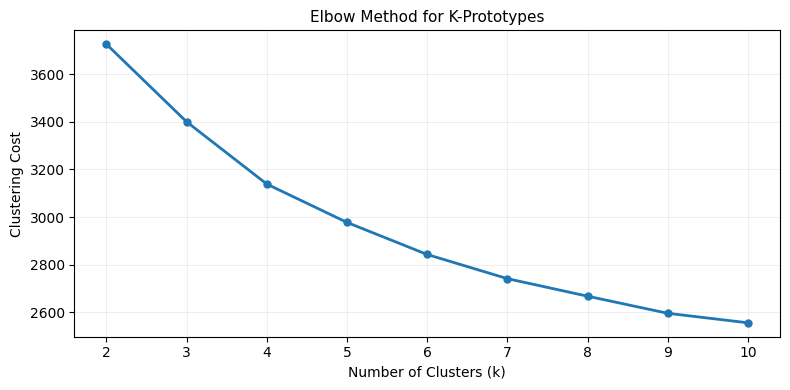

In [16]:
# Convert dataframe to numpy array as required by K-Prototypes.
# Using 'object' dtype allows handling mixed numerical and categorical data.
data_matrix = clustering_data.to_numpy().astype(object)


# Identify categorical feature indices.
# These are required so the algorithm applies:
# - Euclidean distance for numerical features
# - Matching dissimilarity for categorical features
categorical_cols = [
    clustering_data.columns.get_loc(col)
    for col in clustering_data.columns
    if col not in ["Age", "RestingBP", "MaxHR", "Oldpeak"]
]


# Define range of k values to explore.
# We start from k=2 since k=1 is trivial (no real clustering).
K_range = range(2, 11)

# Store clustering cost for each k
cost = []


# Run K-Prototypes for each k value
# This allows us to observe how clustering compactness improves as k increases.
for k in K_range:

    kp = KPrototypes(
        n_clusters=k,

        # Cao initialization is used to reduce sensitivity to random starting points
        # and provide more stable clustering results.
        init='Cao',

        # Multiple initializations reduce the risk of poor local minima
        n_init=5,

        verbose=0
    )

    # Fit model and compute clusters
    kp.fit_predict(data_matrix, categorical=categorical_cols)

    # Store total dissimilarity (cost)
    # Lower cost indicates more compact clusters
    cost.append(kp.cost_)


# Plot Elbow curve
# The goal is to identify where adding more clusters stops giving meaningful improvement.
plt.figure(figsize=(8, 4))

plt.plot(
    K_range,
    cost,
    marker='o',
    linewidth=2,
    markersize=5
)

# Labels and formatting
plt.title("Elbow Method for K-Prototypes", fontsize=11)
plt.xlabel("Number of Clusters (k)", fontsize=10)
plt.ylabel("Clustering Cost", fontsize=10)

plt.xticks(K_range)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

As shown in the figure, the Elbow curve exhibits a smooth and gradual decrease in clustering cost as the number of clusters increases, without a distinct point of sharp change in slope. Instead of forming a clear “elbow” the curve follows a consistent downward trend, indicating that each additional cluster improves the model incrementally without a clear point of diminishing returns. This behavior suggests that the data does not contain well-separated groups, but rather exhibits continuous variation between observations. This is expected in medical datasets, where patient characteristics such as age, blood pressure, and heart rate tend to vary gradually rather than forming sharply distinct categories.

Although the Elbow method is a widely used technique for determining the optimal number of clusters, it may not always provide a clear or reliable indication of k, particularly in complex datasets. In such cases, a deeper analysis is required rather than relying solely on the visual interpretation of the curve. This limitation is well recognized in the clustering literature, where visual methods are considered subjective and may not clearly indicate the optimal number of clusters (Rousseeuw, 1987; Tan et al., 2005).
As a result, no single value of k can be reliably identified from the Elbow method alone. Therefore, further analysis was conducted by evaluating multiple values of k (3–5) using visualization and cluster profiling to determine the most meaningful clustering solution.

### **ii. visulization of cluster separetion**


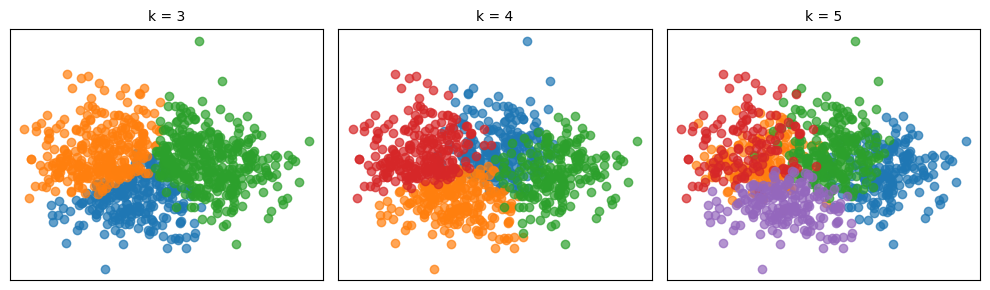

In [ ]:
# Columns
numerical_cols = ["Age", "RestingBP", "MaxHR", "Oldpeak"]
categorical_col_names = clustering_data.columns[categorical_cols]

# PCA 
df_encoded = pd.get_dummies(clustering_data)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_encoded)
pca_base = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

k_values = [3, 4, 5]

# Fit models once 
cluster_results = {}

for k in k_values:
    kp = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=5,
        verbose=0
    )
    clusters = kp.fit_predict(data_matrix, categorical=categorical_cols)
    cluster_results[k] = clusters


fig, axes = plt.subplots(1, len(k_values), figsize=(10, 3))

for i, k in enumerate(k_values):

    clusters = cluster_results[k]

    pca_df = pca_base.copy()
    pca_df['cluster'] = clusters

    ax = axes[i]

    for c in sorted(pca_df['cluster'].unique()):
        subset = pca_df[pca_df['cluster'] == c]
        ax.scatter(subset['PC1'], subset['PC2'], alpha=0.7)

    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

The clustering with **k = 3** shows relatively clear and balanced group separation. The clusters are reasonably distinct with moderate overlap, and each group appears to capture a meaningful portion of the data without excessive fragmentation.

When increasing to **k = 4**, the clusters begin to overlap more, and some groups appear to be split without adding significant new structure. While additional detail is introduced, the separation between clusters becomes less clear.

With **k = 5**, the clustering becomes more fragmented, with noticeable overlap between clusters. The additional clusters do not introduce meaningful differentiation, suggesting over-segmentation of the data.

Based on the two-dimensional PCA visualization, **k = 3 appears to provide a reasonable clustering separation**. However, since this observation is based on a reduced representation of the data, further validation is required. Therefore, a simple cluster profiling analysis was conducted across different cluster sizes. This included examining one categorical feature (Oldpeak) and one numerical feature (Resting Blood Pressure) to better understand the differences between clusters. This further step allows for a more reliable assessment of the clustering results and supports making a final decision regarding the optimal number of clusters.

### **iii. Simple profiling**

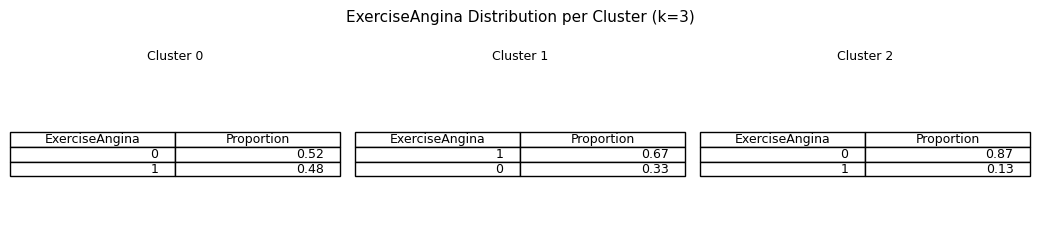

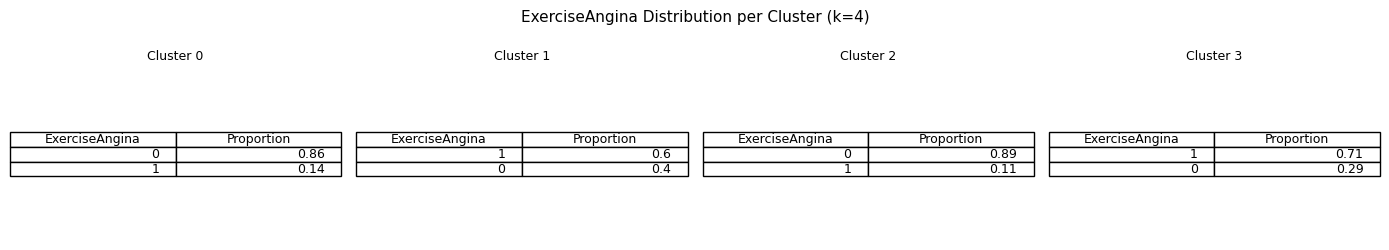

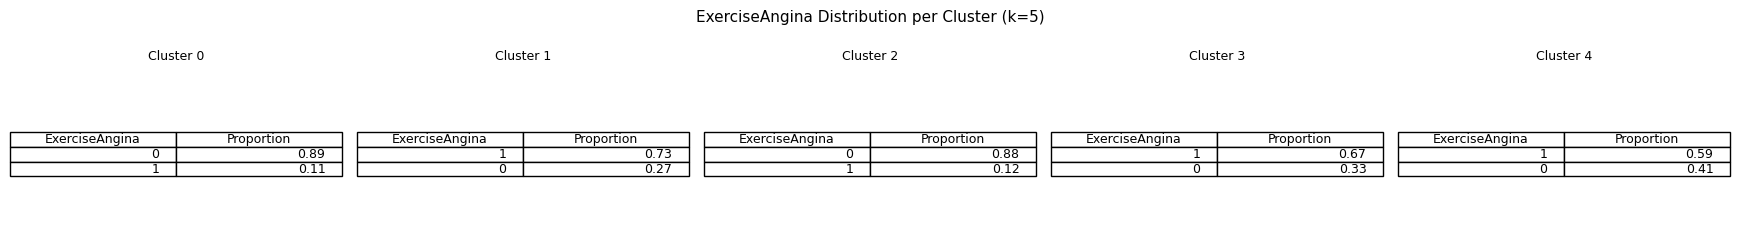

In [ ]:
feature = categorical_col_names[2]  

for k in k_values:

    clusters = cluster_results[k]

    df_temp = clustering_data.copy()
    df_temp['cluster'] = clusters

    fig, axes = plt.subplots(1, k, figsize=(3.5*k, 2.5))
    if k == 1:
        axes = [axes]  

    fig.suptitle(f"{feature} Distribution per Cluster (k={k})", fontsize=11)

    for cluster_id in range(k):

        ax = axes[cluster_id]

        subset = df_temp[df_temp['cluster'] == cluster_id]

        dist = subset[feature].value_counts(normalize=True).round(2)

        table_data = [[idx, val] for idx, val in dist.items()]

        ax.axis('off')
        ax.table(
            cellText=table_data,
            colLabels=[feature, "Proportion"],
            loc='center'
        )

        ax.set_title(f"Cluster {cluster_id}", fontsize=9)

    plt.tight_layout()
    plt.show()


values (0 and 1) represent the categories of the ExerciseAngina feature, where 0 indicates no exercise-induced angina (chest pain) and 1 indicates its presence. The proportions shown reflect the distribution of these categories within each cluster for different k sizes

For **k = 3**, the clusters show a noticeable difference in the distribution of the ExerciseAngina feature. Although the separation is not extreme, each cluster demonstrates a distinct tendency. For example, Cluster 1 is dominated by cases with ExerciseAngina (value = 1), Cluster 2 is mostly composed of cases without ExerciseAngina (value = 0), while Cluster 0 shows a more balanced distribution. This indicates a meaningful level of differentiation between the clusters.

In contrast, when **k = 4**, some clusters become very similar in their distributions. Specifically, Cluster 0 and Cluster 2 are both dominated by value = 0 with very similar proportions, while Cluster 1 and Cluster 3 are both dominated by value = 1. This suggests that the clustering is splitting similar groups into multiple clusters without introducing new meaningful distinctions, resulting in redundancy and over-segmentation.

Wheres In **k = 5** , the clustering becomes more fragmented, and several clusters exhibit very similar distributions of the ExerciseAngina feature. Specifically, Cluster 0 and Cluster 2 are both dominated by value = 0 with nearly identical proportions (0.89 and 0.88), indicating that they represent almost the same group. Similarly, Cluster 1 and Cluster 3 are both dominated by value = 1 with comparable proportions (0.73 and 0.67), suggesting redundancy between these clusters. Cluster 4 also leans toward value = 1 (0.59), but with a more balanced distribution, making it less distinct. Overall, the presence of multiple clusters with very similar distributions indicates that the data is being over-segmented. Instead of revealing new meaningful patterns, increasing the number of clusters to 5 leads to duplication of similar groups without adding interpretive value.


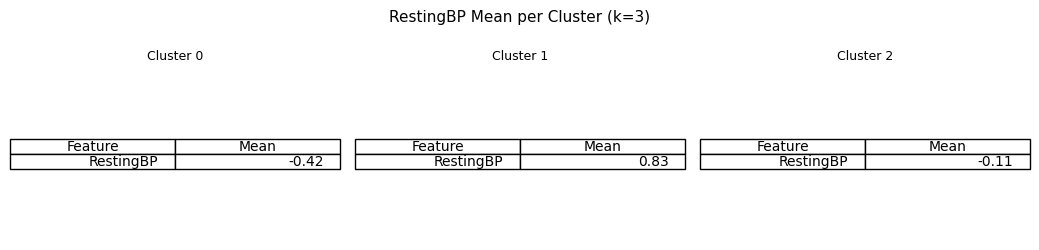

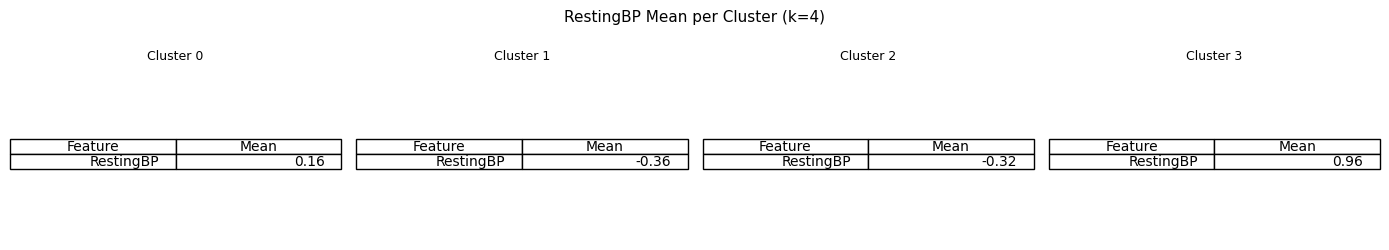

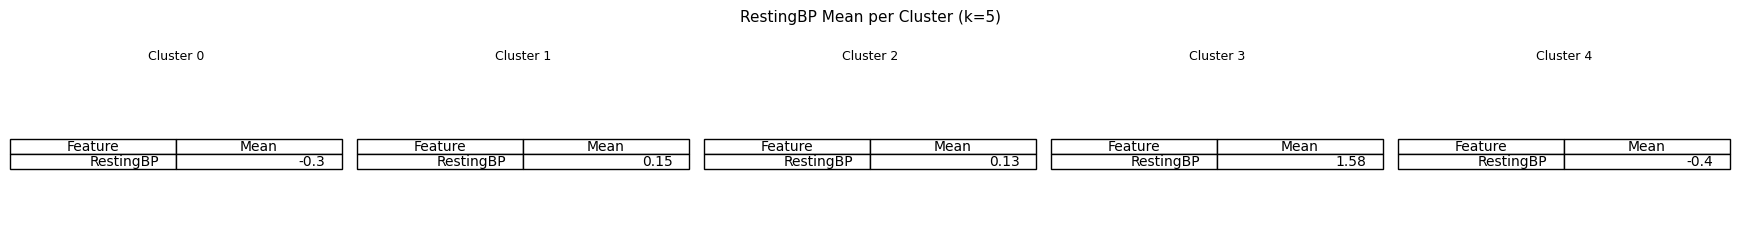

In [ ]:
num_feature = numerical_cols[1]  

for k in k_values:

    clusters = cluster_results[k]

    df_temp = clustering_data.copy()
    df_temp['cluster'] = clusters

    fig, axes = plt.subplots(1, k, figsize=(3.5*k, 2.5))
    if k == 1:
        axes = [axes]

    fig.suptitle(f"{num_feature} Mean per Cluster (k={k})", fontsize=11)

    for cluster_id in range(k):

        ax = axes[cluster_id]

        subset = df_temp[df_temp['cluster'] == cluster_id]

        mean_val = subset[num_feature].mean().round(2)

        table_data = [[num_feature, mean_val]]

        ax.axis('off')
        ax.table(
            cellText=table_data,
            colLabels=["Feature", "Mean"],
            loc='center'
        )

        ax.set_title(f"Cluster {cluster_id}", fontsize=9)

    plt.tight_layout()
    plt.show()
    

MUST ADD HERE

based on the Elbow method, visualization of cluster separation, and an abstract level of feature profiling to assess the underlying data groupes, the **the selected number of clusters was determined to be k = 3**.

This choice provides a balanced clustering solution, as it captures meaningful variation in the data without introducing unnecessary complexity. Compared to k = 2, which is overly simplistic and limits the diversity of the clusters, k = 3 offers a more representative segmentation of the data while maintaining interpretability, without introducing the redundancy and complexity observed in k = 4 and 5.

### 3.3 Choosing appropratie gamma value

In K-Prototypes, the gamma parameter controls the relative importance of categorical features compared to numerical ones. As discussed by Zhexue Huang, the selection of gamma is not fixed and is typically determined by the user based on the dataset characteristics and the desired balance between feature types. By default, gamma is automatically estimated based on the spread of numerical features, typically using a function of their standard deviation. This provides a general balance between numerical and categorical components without requiring manual tuning. However, this default setting does not explicitly account for the imbalance in the number of categorical and numerical variables. In this study, the dataset contains a significantly larger number of categorical features being 16 compared to numerical ones being 4. Relying solely on the default gamma could therefore lead to an unintended bias in the clustering process, where categorical attributes disproportionately influence the results.

For this reason, a sensitivity analysis was conducted using a limited range of gamma values rather than performing an exhaustive grid search. This approach is more suitable in unsupervised learning settings, where no ground truth labels are available for objective evaluation. Given the relatively high number of categorical features (16 features), smaller gamma values were intentionally considered. Larger gamma values would overemphasize categorical similarity, causing it to dominate the clustering process and reduce the influence of numerical features. By testing a controlled range of lower gamma values, a more balanced contribution between feature types can be achieved, leading to more interpretable clustering results

---

# **HDBSCAN**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is HDBSCAN Algorithm?**

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that builds a hierarchy of clusters based on density. It is an extension of the DBSCAN method, which is a density-based clustering method. However, DBSCAN struggles with the assumption of global density, meaning it uses the same density threshold for all clusters. This often does not comply with medical datasets or many real world datasets in general , where clusters may have varying densities and sizes. Unlike DBSCAN, HDBSCAN can identify these variations effectively.

One of the most interesting features of the HDBSCAN algorithm is its ability to decide the optimal number of clusters while remaining robust to noise and outliers. These outliers are prevalent in our medical dataset and cannot be ignored, as they may represent significant clinical cases. This process of selecting the appropriate number of clusters is handled systematically by examining cluster stability across various density thresholds.


### **How does it work?**

The HDBSCAN algorithm consist of two phases:

- ***Mutual Reachability Graph***\
The algorithm starts by computing the core distance $d_c$ for all points. This represents the distance between a point $x_p$ and its $n$-th nearest neighbor $x_{s}, where $n$ is defined by the `min_samples` parameter. The smaller core distance the more points near to it the more density spot the point in. It calculated by the following formula:  $$d_c(x_p) = d(x_p, x_s)$$\
Then it calculates the mutual reachability distance $d_m$ between every pair points using the following formula: $$d_m(x_p, x_q) = \max \{d_c(x_p), d_c(x_q), d(x_p, x_q)\}$$ By taking the maximum, the algorithm effectively spreads out points that are in sparse regions.Thus, even if two points are close to each other. if one of them is in a low-density spot (large $d_c$), the mutual reachability distance between them will be larger. This gives a small distance between points that are both close to each other and located in high-density regions.\
After the computing mutual reachability distances, the algorithm builds the mutual reachability graph $G_{ms}$, where each data point represented as a vertex, and the edges between points represent the mutual reachability distance between them.

- ***Hierarchical Clustering***\
As we mentioned before, the HDBSCAN finds the appropriate number of clusters by examining clusters stability across various density thresholds **$\epsilon$**. This gives all connected parts for all **$\epsilon$** values. This done as the following:
1. Extracting a minimum spanning tree (MST) of $G_{ms}$, that is the subset of edges that connects all vertices together, without any cycles, and with the minimum possible total edge weight.
2. Adding a "self edge" for each vertex on the MST with a weight equals to its core distance.
3. Create a single cluster that contains the whole MST.
4. Finding the edges with the greatest weight (core distance) and remove them to splits the vertex groups connected with a weak edge, generating two **connected components**.
5. Labeling the connected components (clusters).
    1. If a connected component contains only one vertex (no edge) or less than `min_cluster_size` parameter if specified, label it as null (noise).
    2. If a connected component contains more than one vertex label it as a new cluster.
6. Repeat 4-5 until there are no more connected components (clusters become stable).

### **Why is HDBSCAN suitable for our data?**

#### i. Dataset size & feature types

The HDBSCAN algorithm affected by high-dimensional spaces (50-100 features) and can result in curse of dimensionality unless dimensionality reduction techniques applied [-], however our dataset were shrink after performing multiple experiments by researchers to includes only the top 20 important features as their consequences (other illnesses) affects the heart disease [-]. Consequently, dimensionality is not a concern, as 20 features does not considered high-dimensional and as our sample size ($N = 917$) exceeds the recommended 10–20 times the number of features.

It is also capable of handling mixed data types including both continuos and categorical features as long as the categorical features are appropriately preprocessed (e.g., One-Hot Encoding for nominal data and Label Encoding for ordinal data). Our preprocessing pipeline has already addressed these requirements, making HDBSCAN suited for our dataset.

The HDBSCAN algorithm considered a good choice for complex datasets like our medical dataset, as it is able to handle sparse clusters with varying shapes and densities of patients. These variations results from the various combinations of features that leads to herat disease and other diseases that can result from those combinations and cause a heart disease, some of those caused combinations have a high density ( combinations associated with high occurrence heart disease cause like Diabetes) others can have low density ( unpopular heart disease causes and conditions), the HDBSCAN can handle this density variation problem and not only specify a single density threshold.

---

#### ii. Expected cluster shapes

---

#### iii. Scalability & interpretability

- **Scalability** \
In the theoretical explanation of HDBSCAN algorithm, the process of finding the nth-nearest neighbor (used to computed the core distance) is expensive with a time complexity of O($n_2$), since it compute the distances between all pairs of points. However, the implementation can be optimize to approximately O(n log n) using KD-trees for low-dimensional data (less than 20). As the dimensionality increases, the efficiency of KD-trees degrades due to the Curse of Dimensionality, and alternatives such as Ball Trees are used, although performance still worsens with higher dimensions. \
\
 Another theoretical complexity is building a graph that contains all edges ( based on mutual reachability distances), it take O($n_2$) as every vertex should be connected to every other vertexes. To optimize this, the algorithm use MST tree (Minimum Spanning Tree ) that contains the minimum set of edges that dropping any edge results in disconnected components (no cycles), and this set of edges should contains the minimum total wights. \
 \
  To further improve efficiency, the MST is not built over the full graph, but instead it built over a k-nearest neighbor graph, significantly reducing the number of edges. Additionally, the implementation uses Borůvka's algorithm (or its optimized variants), which has a time complexity of approximately O(|E| log |V|) in the worst case, where |E| is the number of edges and |V| is the number of vertices. \
  \
  This gives an approximately total time complexity O(n log n) for low-dimensional data which our dataset is around, but it can degrade toward O($n_2$) in high-dimensional spaces.

- **Interpretability**  \
The Interpretability in clustering algorithms defined by the ability to understanding the structure of clusters and their formation. The HDBSCAN algorithm produces a hierarchical structure and identifies noise. This hierarchical organization can facilitate interpretation by allowing users to explore clusters at different levels of granularity. However, it does not provide simple representations such as centroids. \
\
The hierarchical structure of clusters and noise identification is important for our dataset, as it helps in associating different types of patients within a hierarchical framework, which gives a valuable insights into relationships between patient groups at multiple levels, while also identifying outliers that may represent important or unusual medical cases.